# Stent skeletonisation — interactive pipeline

[output] reusing existing folder as-is: /Users/vural/Desktop/RWTH - SiSc/Projects/Github/stentFIT/examples/notebook_outputs/16crownCrimpedXienceStent+extremaSupports
[resume] loading point cloud from /Users/vural/Desktop/RWTH - SiSc/Projects/Github/stentFIT/examples/notebook_outputs/16crownCrimpedXienceStent+extremaSupports/crown_points.csv ...
[resume] restored 14 per-crown 2D skeletons + 16,172,128 surface points. Ready for the manual-edit step.
[resume] using in-memory state (normal run).

Assembled 2D skeleton: 103,683 points | pixel_size median = 0.00273
[wrap] downsampled surface for the wrap: 16,172,128 -> 2,000,000 pts (wrap_max_surf)
[collapse_junctions] collapsed 190 cluster(s); junction nodes 1921 -> 133; total nodes 103683 -> 101972 (edge-connected contraction)
[prune_spurs] removed 1871 nodes in 78 spur branch(es); remaining non-tip endpoints: 0

Skeleton finalised: 100,101 points (82 junctions, 0 endpoints)
[saved] /Users/vural/Desktop/RWTH - SiSc/Projects/Github/stentFIT

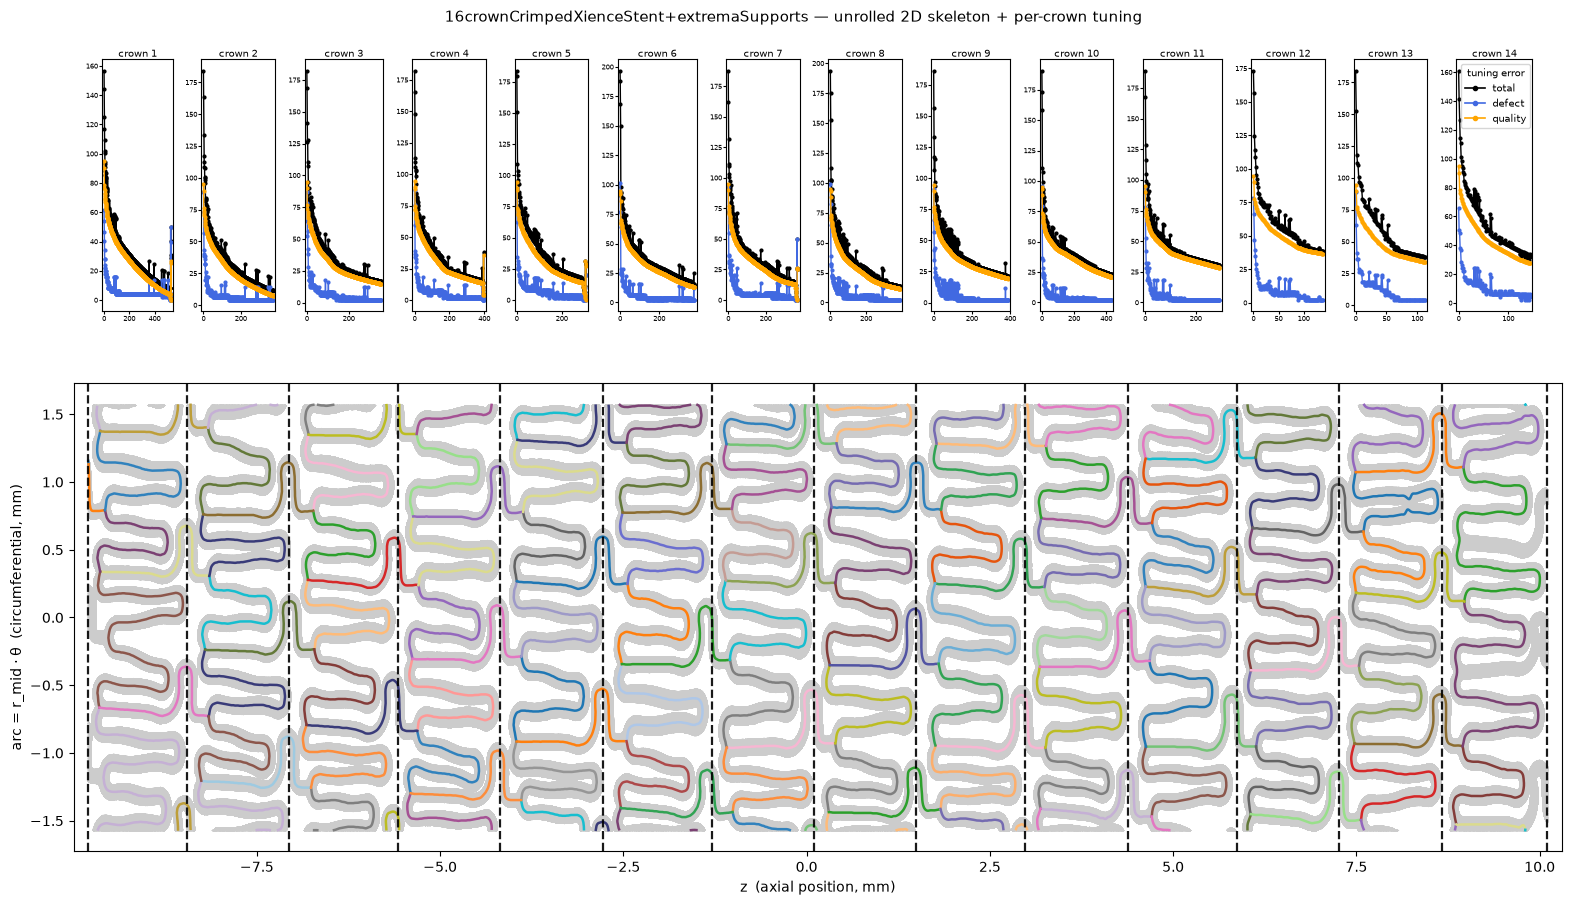

[saved] /Users/vural/Desktop/RWTH - SiSc/Projects/Github/stentFIT/examples/notebook_outputs/16crownCrimpedXienceStent+extremaSupports/skeleton_splines_2d.png  (123 curves, 15 crown boundaries, 14/14 crown tuning plots)
[saved] /Users/vural/Desktop/RWTH - SiSc/Projects/Github/stentFIT/examples/notebook_outputs/16crownCrimpedXienceStent+extremaSupports/skeleton_splines_2d.html
[saved] /Users/vural/Desktop/RWTH - SiSc/Projects/Github/stentFIT/examples/notebook_outputs/16crownCrimpedXienceStent+extremaSupports/skeleton_splines_trimesh.html
[saved] /Users/vural/Desktop/RWTH - SiSc/Projects/Github/stentFIT/examples/notebook_outputs/16crownCrimpedXienceStent+extremaSupports/skeleton_splines.glb  (123 spline curves)
[folder] read stent_features.json from /Users/vural/Desktop/RWTH - SiSc/Projects/Github/stentFIT/examples/notebook_outputs/16crownCrimpedXienceStent+extremaSupports
[folder] strut_thickness = 0.2052 mm

Meshed 123/123 curves (0 skipped) into a 1D beam mesh:
  5,727 nodes, 2,802 Bea

In [1]:
# poetry build
# conda create -n test_stentfit python=3.13 
# conda activate test_stentfit
# pip install "dist/stentfit-0.1.0-py3-none-any.whl"
# python 

from stentfit import stent_pipeline

STENT_NAME = "16crownCrimpedXienceStent+extremaSupports"
STL_FILE   = f'/Users/vural/Desktop/RWTH - SiSc/Projects/Github/stentFIT/data/stent_designs/{STENT_NAME}.stl'
OUTPUT_DIR = f'/Users/vural/Desktop/RWTH - SiSc/Projects/Github/stentFIT/examples/notebook_outputs/{STENT_NAME}'

RANDOM_SEED     = 0
REMOVE_SUPPORTS = (STENT_NAME == '16crownCrimpedXienceStent+extremaSupports')

AUTO_TUNE        = True       
PIXELS_PER_STRUT = 10
DILATE_PX        = 3
TUNE_TIME_LIMIT  = 120     

MESH_BEAMS = True
L_EL = 0.1
YOUNGS_MODULUS = 2.0e5
POISSON_RATIO = 0.3
DENSITY = 0.0
BEAM_CLASS_LABEL = 'Beam3rHerm2Line3'

stent_pipeline(
    stl_file=str(STL_FILE),
    output_dir=str(OUTPUT_DIR),
    stent_name=STENT_NAME,
    mesh_beams=MESH_BEAMS,
    remove_supports=REMOVE_SUPPORTS,
    random_seed=RANDOM_SEED,
    auto_tune=AUTO_TUNE,
    pixels_per_strut=PIXELS_PER_STRUT,
    dilate_px=DILATE_PX,
    tune_time_limit=TUNE_TIME_LIMIT,
    l_el=L_EL,
    youngs_modulus=YOUNGS_MODULUS, 
    poisson_ratio=POISSON_RATIO,
    density=DENSITY,
    beam_class_label=BEAM_CLASS_LABEL)

#conda deactivate
#conda remove -n test_stentfit --all -y  
